In [47]:
import numpy as np
import pandas as pd 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [25]:
from ydata_profiling import ProfileReport

In [26]:
%pip install "setuptools<81" --force-reinstall

  Using cached setuptools-80.10.2-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-80.10.2-py3-none-any.whl (1.1 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.10.2
    Uninstalling setuptools-80.10.2:
      Successfully uninstalled setuptools-80.10.2
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pkg_resources
print("pkg_resources works!")

pkg_resources works!


In [28]:
df= pd.read_csv(r"D:\MASTERS\FOML\assign\202618026_AumTailor_DS605\202618026_lab_05\garments_worker_productivity.csv")

In [29]:
df.sample(6)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
553,2/1/2015,Quarter1,sweing,Sunday,9,0.75,29.12,1282.0,6960,45,0.0,0,0,58.0,0.750593
271,1/15/2015,Quarter3,finishing,Thursday,7,0.80,2.90,NaN,1440,0,0.0,0,0,8.0,0.689299
799,2/16/2015,Quarter3,sweing,Monday,11,0.70,11.41,680.0,2160,30,0.0,0,2,54.0,0.565972
205,1/12/2015,Quarter2,sweing,Monday,6,0.80,11.41,843.0,5670,50,0.0,0,0,31.5,0.800182
1102,3/7/2015,Quarter1,finishing,Saturday,8,0.80,4.60,NaN,3600,0,0.0,0,0,15.0,0.590741
529,1/31/2015,Quarter5,finishing,Saturday,8,0.65,3.94,NaN,960,0,0.0,0,0,8.0,0.971867


In [30]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [32]:
df[['quarter', 'department','day']].apply(lambda x: list(x.unique())).to_dict()

{'quarter': ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5'],
 'department': ['sweing', 'finishing ', 'finishing'],
 'day': ['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']}

In [33]:
df['department'] = df['department'].str.strip()

In [34]:
df[['quarter', 'department','day',]].apply(lambda x: list(x.unique())).to_dict()

{'quarter': ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5'],
 'department': ['sweing', 'finishing'],
 'day': ['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']}

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df['team'].unique()

array([ 8,  1, 11, 12,  6,  7,  2,  3,  9, 10,  5,  4])

In [37]:
df.isnull().mean()*100

date                      0.000000
quarter                   0.000000
department                0.000000
day                       0.000000
team                      0.000000
targeted_productivity     0.000000
smv                       0.000000
wip                      42.272348
over_time                 0.000000
incentive                 0.000000
idle_time                 0.000000
idle_men                  0.000000
no_of_style_change        0.000000
no_of_workers             0.000000
actual_productivity       0.000000
dtype: float64

In [38]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\AUM\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [39]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\AUM\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [40]:
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
%pip install numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
profile = ProfileReport(
    df,
    title="Dataset Profiling Report",
    explorative=True
)

In [43]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
profile.to_file("dataset_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 318.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

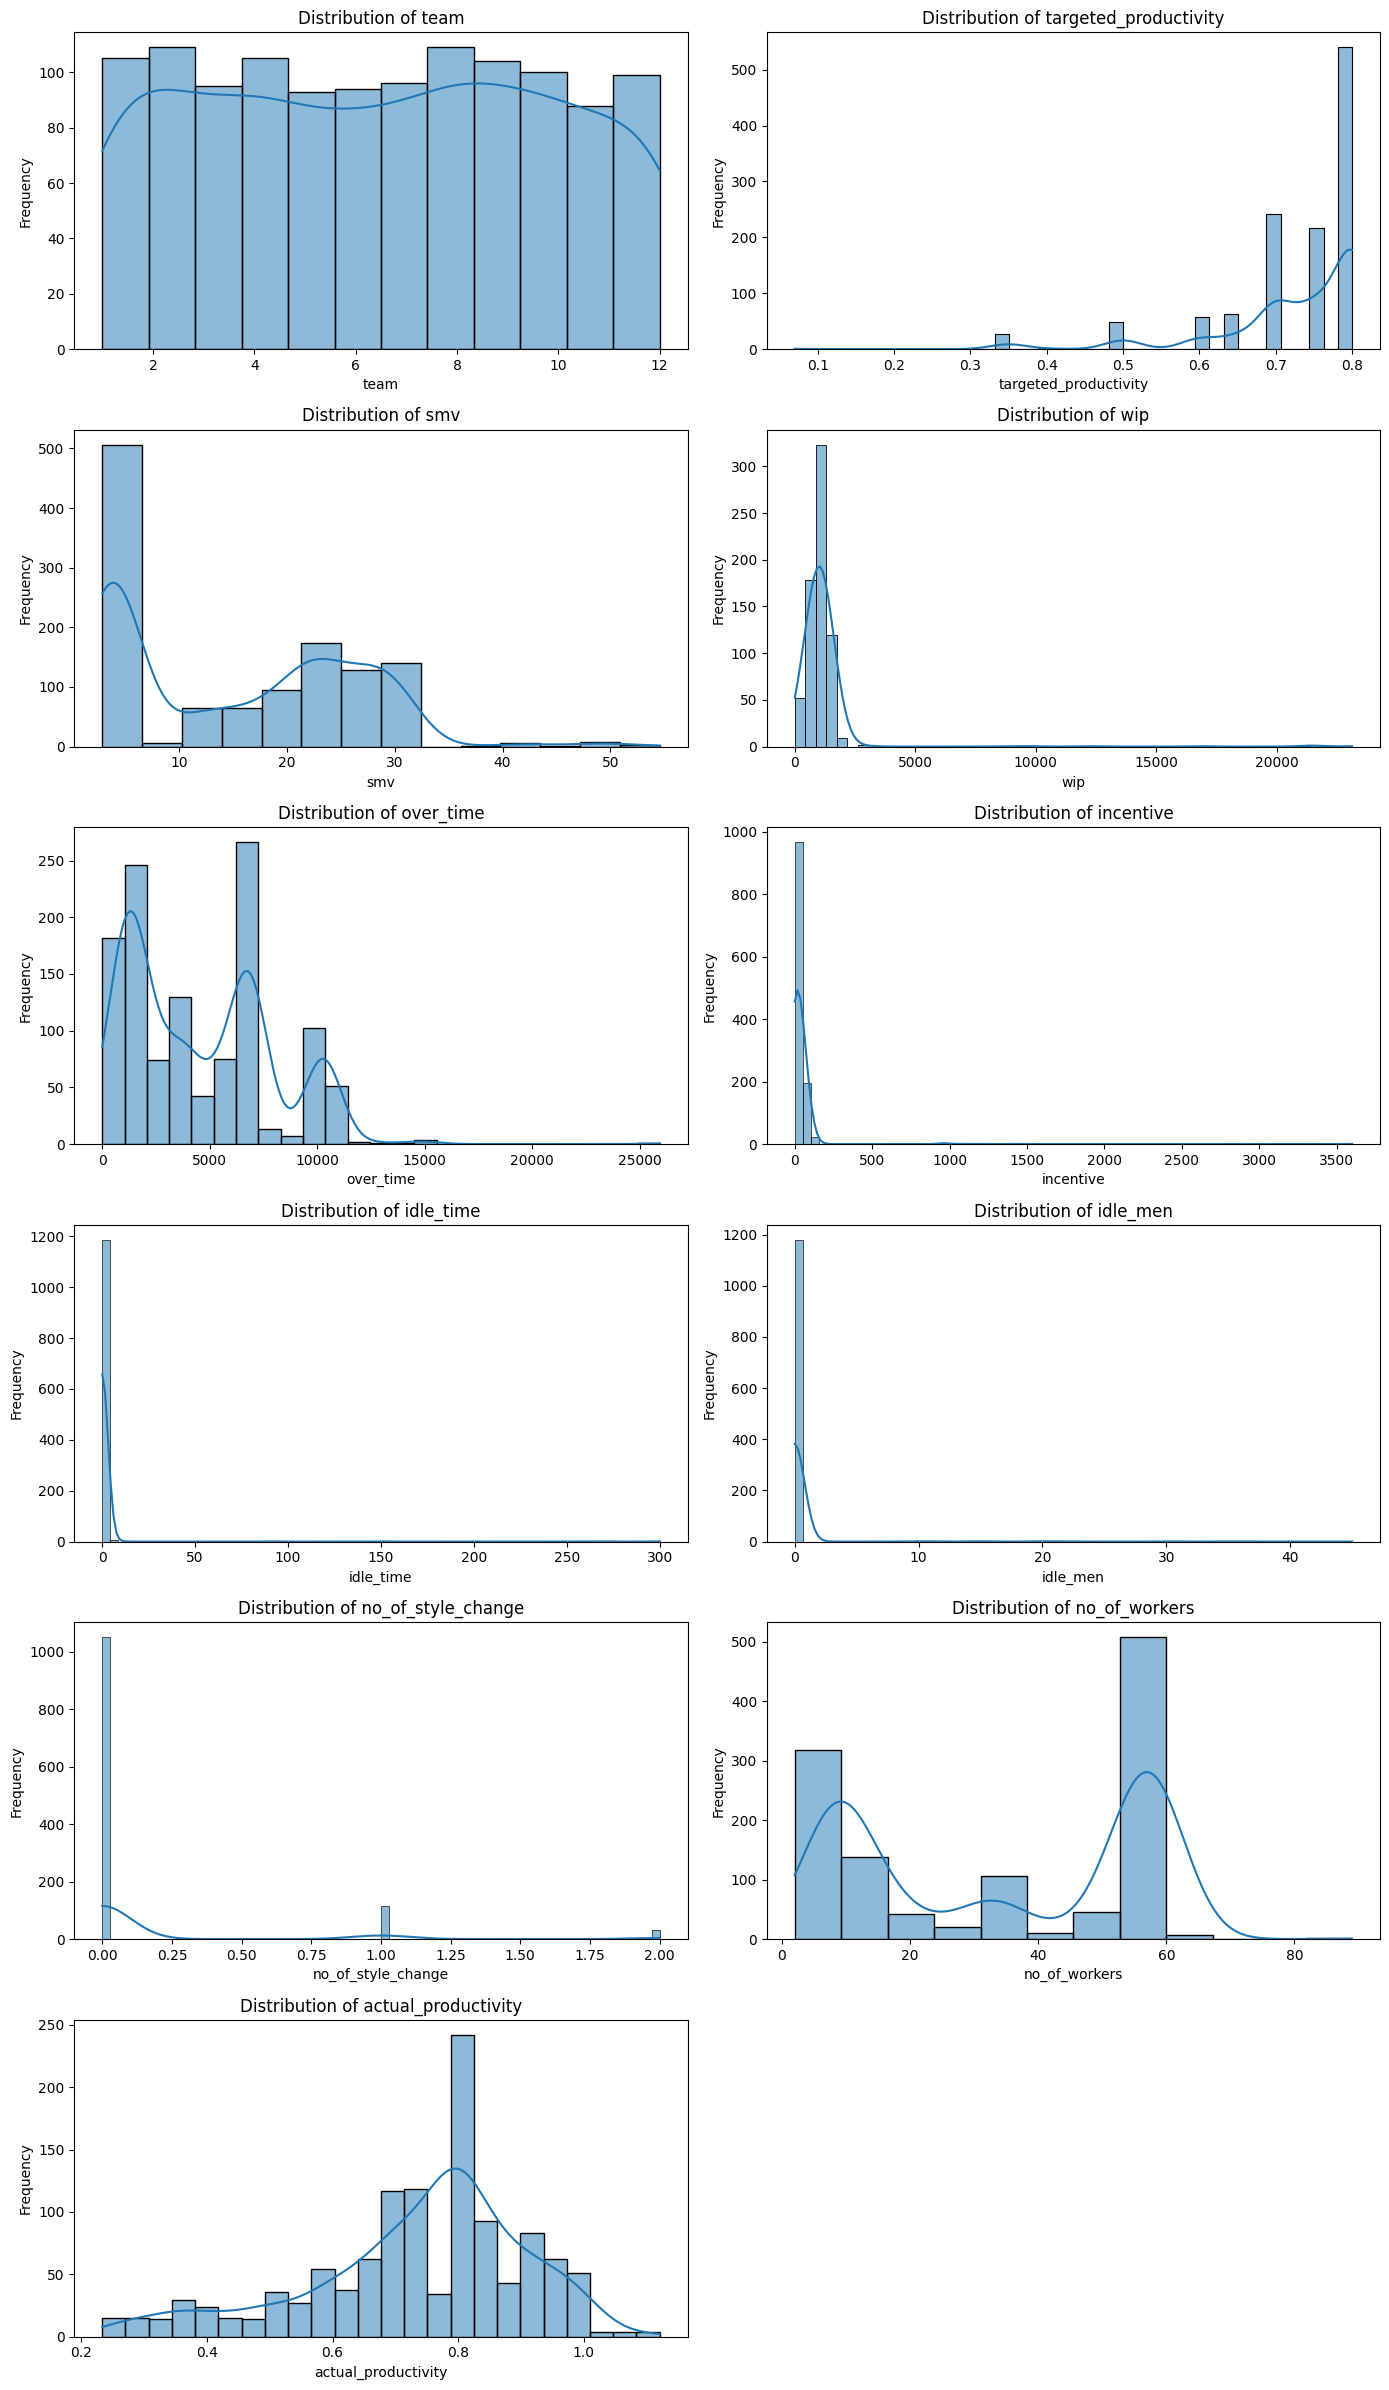

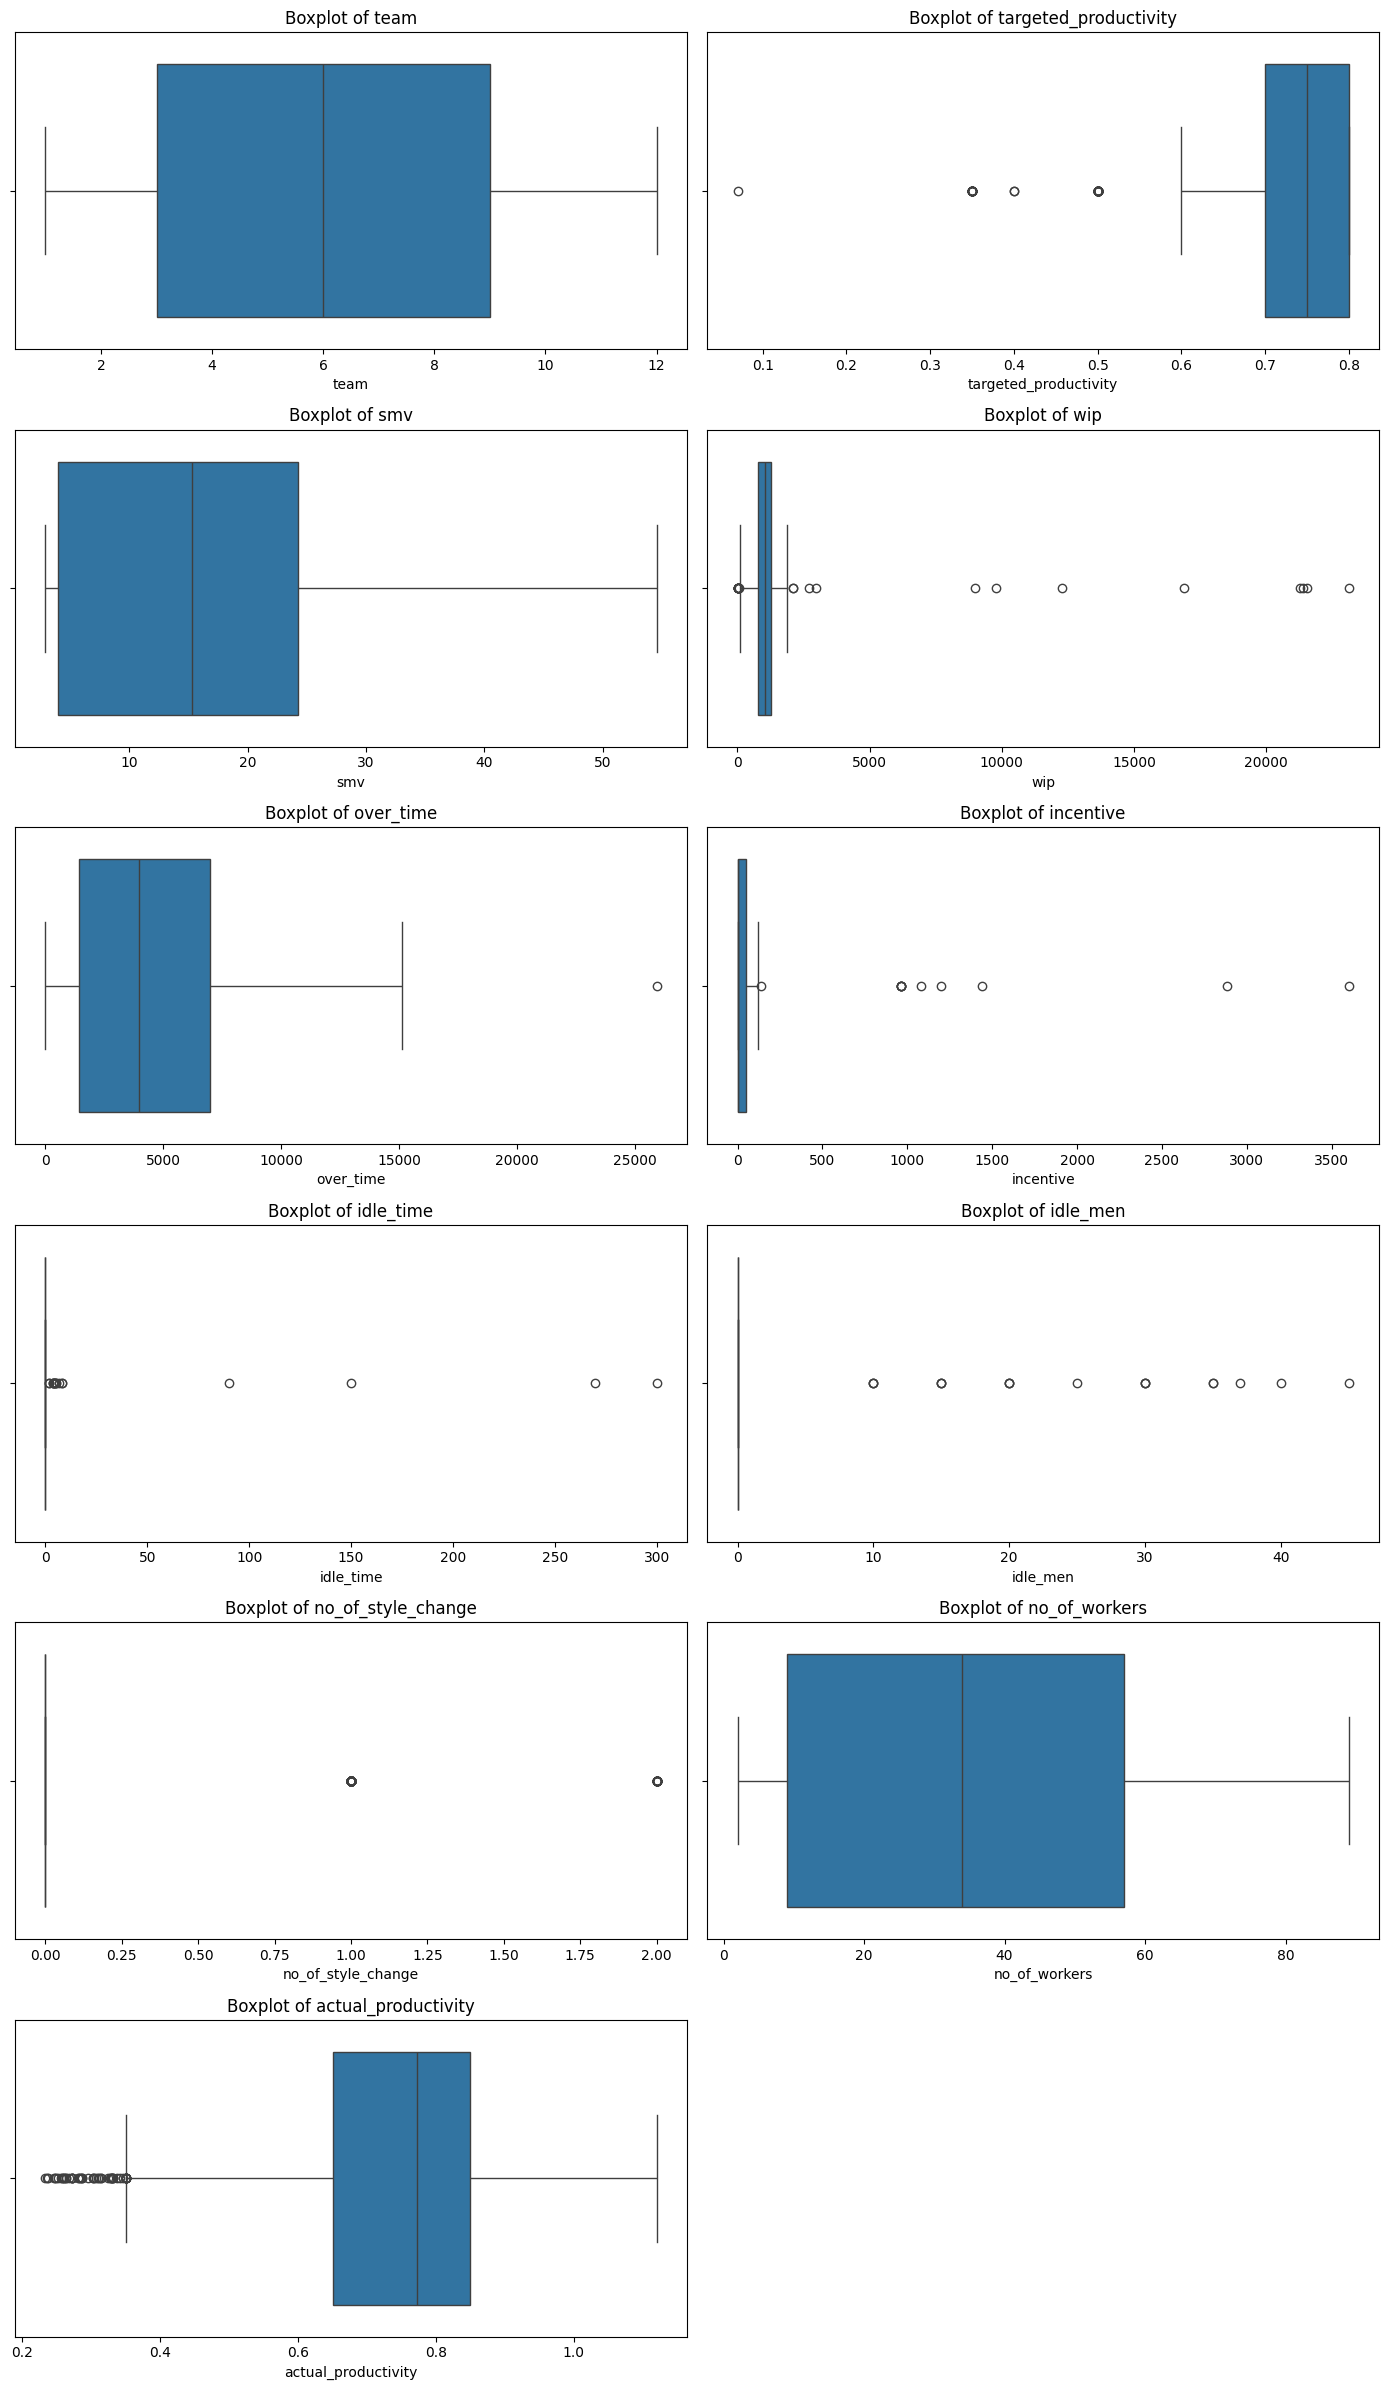

In [48]:
num_cols = df.select_dtypes(include='number').columns

n = len(num_cols)
cols = 2
rows = (n + cols - 1) // cols

# Histograms
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


# Boxplots
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df['actual_productivity'].describe()

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

In [ ]:
(df['actual_productivity'] > 1).sum()

np.int64(37)

In [ ]:
df = df[df['actual_productivity'] <= 1]
df['actual_productivity'].describe()

count    1160.000000
mean        0.725991
std         0.169404
min         0.233705
25%         0.650061
50%         0.754425
75%         0.845167
max         0.999995
Name: actual_productivity, dtype: float64

<Axes: xlabel='actual_productivity', ylabel='Count'>

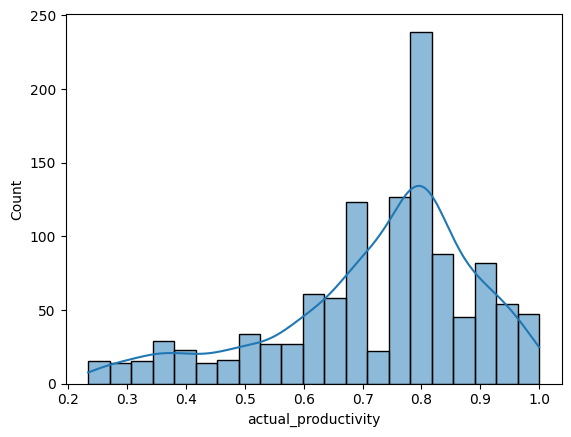

In [ ]:
sns.histplot(df['actual_productivity'],kde = True)

<Axes: ylabel='actual_productivity'>

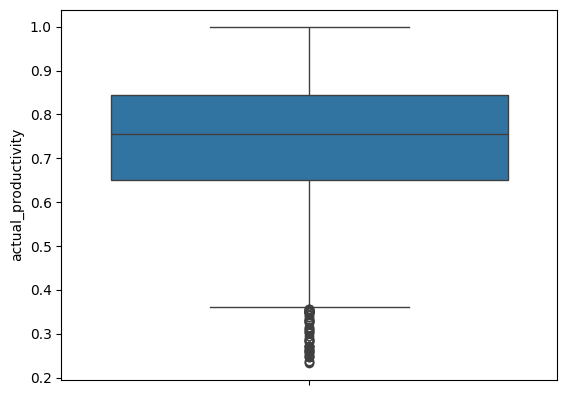

In [ ]:
sns.boxplot(df['actual_productivity'])

In [ ]:
df['actual_productivity'].skew()

np.float64(-0.9091112862259763)

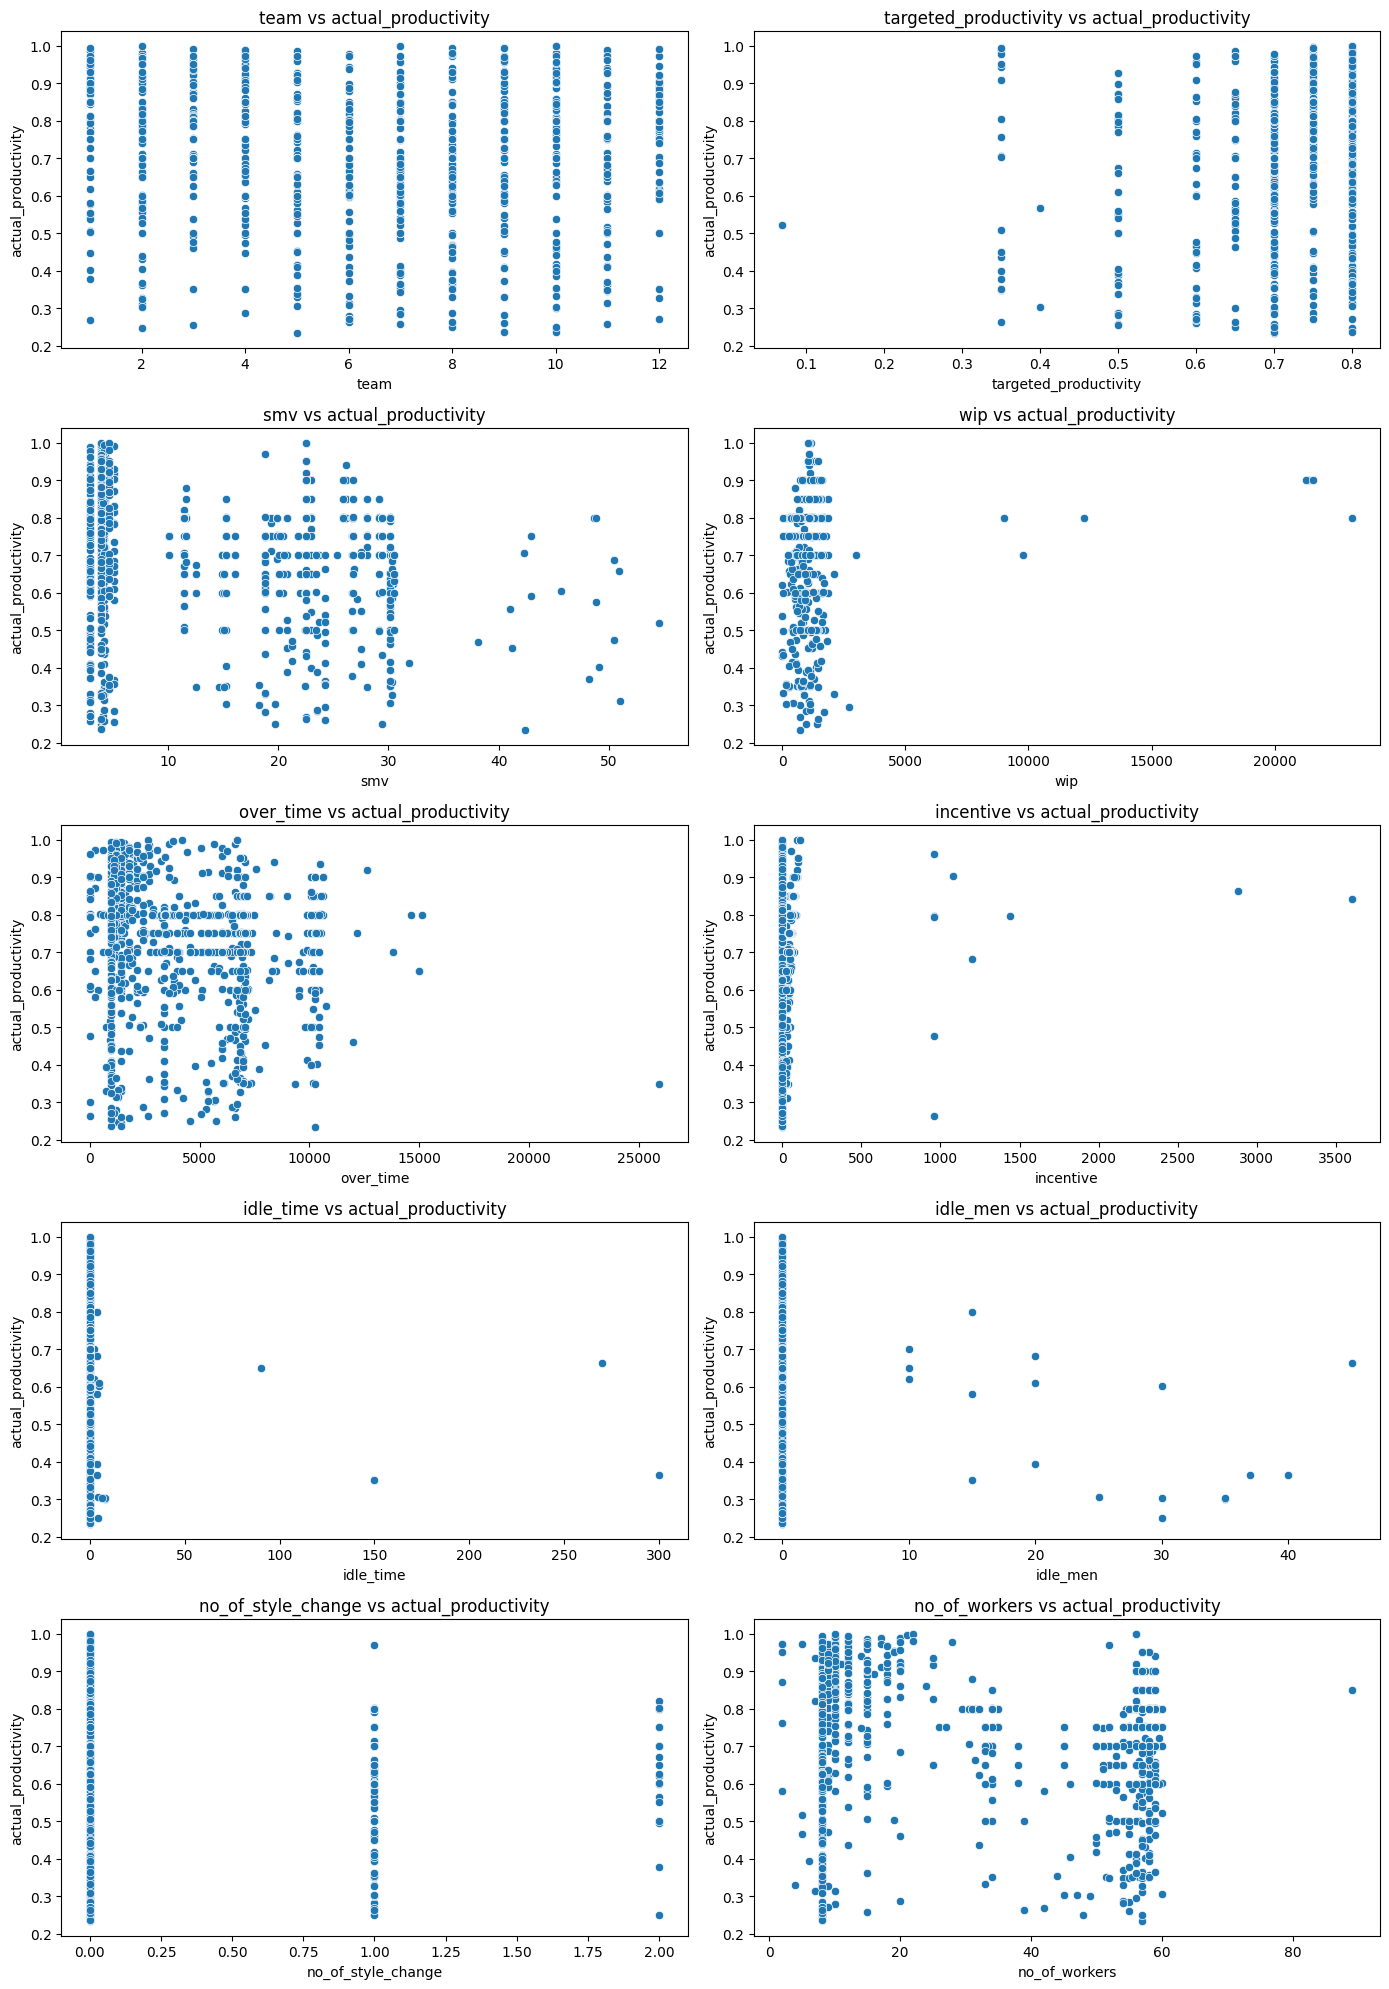

In [ ]:
target = 'actual_productivity'

num_predictors = df.select_dtypes(include='number').columns.drop(target)

n = len(num_predictors)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_predictors):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
correlation = df[num_predictors.tolist() + [target]].corr()[target].drop(target)

print(correlation.sort_values())

no_of_style_change      -0.198167
idle_men                -0.184021
smv                     -0.133491
team                    -0.100026
idle_time               -0.081463
no_of_workers           -0.078635
over_time               -0.050351
incentive                0.068635
wip                      0.114506
targeted_productivity    0.414307
Name: actual_productivity, dtype: float64


In [ ]:
outlier_cols = [
    'idle_men',
    'idle_time',
    'wip',
    'incentive',
    'over_time',
    'no_of_style_change'
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Lower:", lower)
    print("Upper:", upper)
    print("Outliers:", ((df[col] < lower) | (df[col] > upper)).sum())


idle_men
Lower: 0.0
Upper: 0.0
Outliers: 18

idle_time
Lower: 0.0
Upper: 0.0
Outliers: 18

wip
Lower: 64.875
Upper: 1923.875
Outliers: 21

incentive
Lower: -75.0
Upper: 125.0
Outliers: 10

over_time
Lower: -6840.0
Upper: 15240.0
Outliers: 1

no_of_style_change
Lower: 0.0
Upper: 0.0
Outliers: 147


In [49]:
# Save cleaned dataset
df.to_csv("cleaned_productivity.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df.shape)

Cleaned dataset saved successfully.
Shape: (1197, 15)
